<h1>Model Building - Q5</h1>

*Organzing Data*

In [4]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [5]:
val_df = pd.read_csv("val_metadata.csv") 
val_df = val_df.rename(columns={'photo_id': 'filename', 'label': 'class'})
val_df['filename'] = val_df['filename'].apply(lambda x: f"split_photos/val/{x}.jpg")
print(val_df.head())

                                      filename             business_id  \
0  split_photos/val/qTHLTmC0JrNrjKqmIPHWjQ.jpg  MHjGuP2KQXwJj8qkuwhC6g   
1  split_photos/val/793--1wXQIwtK0QobQDaQg.jpg  IvAa7PvfOYl0xRML5W3ebg   
2  split_photos/val/jW7yuoi_xFSLpswHtZrYgg.jpg  zWnIqm5LrKXZQY0VfbZXhg   
3  split_photos/val/VaDLl1VRq_0MYCuRPSzKsA.jpg  bU0GQYpZWKM4xz7D8Rz6hA   
4  split_photos/val/R9U94rP_JmoV5Wpjrngr8Q.jpg  wA5kqFd2XtxcuUAmwuqWdg   

        caption  class  
0           NaN  drink  
1           NaN  drink  
2           NaN   food  
3           NaN  drink  
4  Black Forest   food  


In [6]:
train_df = pd.read_csv("train_metadata.csv")
train_df = train_df.rename(columns={'photo_id': 'filename', 'label': 'class'})
train_df['filename'] = train_df['filename'].apply(lambda x: f"augmented_photos/train/{x}_aug.jpg")
print(train_df.head())

                                            filename             business_id  \
0  augmented_photos/train/4qu5Yb4zpKEPMHnIokvsFw_...  3LN-a28iwqL4EcuN3SXqsg   
1  augmented_photos/train/IhOOEqw65z-qWMcYxz9Ysg_...  MlW6HlXSJAc1vIiH2Nueow   
2  augmented_photos/train/7NVdtW5E7liFMvGnW6kckw_...  RS4epErt5vEvSCp-U7Or3g   
3  augmented_photos/train/swsTtxXEbEixoZjkOZNgVQ_...  FGGDERcsTDYt6uLHPWEKrw   
4  augmented_photos/train/hqZxiY-ISxEwXARWH6u7vA_...  agRssYozLGjGEsBZAo1Cbw   

                                             caption    class  
0                                                NaN  outside  
1  The guys working Saturday at 6 pm were the fri...    drink  
2                                                NaN   inside  
3                       For gluten free customers...     menu  
4                                                NaN    drink  


In [7]:
test_df = pd.read_csv("test_metadata.csv")
test_df = test_df.rename(columns={'photo_id': 'filename', 'label': 'class'})
test_df['filename'] = test_df['filename'].apply(lambda x: f"split_photos/test/{x}.jpg")
print(test_df.head())

                                       filename             business_id  \
0  split_photos/test/bdTdwyFDbb9NdjBOQGamaQ.jpg  52iW9Eo-EWJZXYYjQ5pAKw   
1  split_photos/test/adXfpHpKxd3rHRFXgytG0A.jpg  _LgI5387qAmMuS8i6h69cg   
2  split_photos/test/cvfjsiUk1UzGGomb4mCtpQ.jpg  K5gNiYeNriJsaqyJewZl0w   
3  split_photos/test/u4Xr1h2YIAONEGqWS_K7RA.jpg  9OCsSHr6OCSyR91BFIbszQ   
4  split_photos/test/f8kmnyacWttiSBEL4ryygA.jpg  l4IeGBHXV2E8S8COd9rx9A   

                                             caption    class  
0                                                NaN   inside  
1  NO. 52 - Bourbon * House Made Blueberry Shrub ...    drink  
2  Nachos can be loaded w/ grilled adobo chicken,...     food  
3                                                NaN  outside  
4  Doing our #ShopLocal #SmallBizSaturday spendin...     menu  


Removing Missing Files

In [8]:
import os

train_df = train_df[train_df['filename'].apply(os.path.exists)]
val_df = val_df[val_df['filename'].apply(os.path.exists)]
test_df = test_df[test_df['filename'].apply(os.path.exists)]


In [9]:
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='class',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)
val_gen = datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='class',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)
test_gen = datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col='class',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False   # Important for evaluation
)

num_classes = len(train_gen.class_indices)


Found 17192 validated image filenames belonging to 5 classes.
Found 2146 validated image filenames belonging to 5 classes.
Found 2149 validated image filenames belonging to 5 classes.


**Model Building**

In [19]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True  # All layers will be trained!

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         262,6

 Total params: 14,979,909 (57.14 MB)

 Trainable params: 14,979,909 (57.14 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
import time
from PIL import Image
import numpy as np
start = time.time()
for i, row in train_df.head(100).iterrows():
    img = Image.open(row['filename'])
    img = img.resize((224,224))
    img = np.array(img)
print("Time to read and resize 100 images:", time.time() - start)


Time to read and resize 100 images: 0.723935604095459


In [43]:
import time

start_time = time.time()
checkpoint = ModelCheckpoint('model_checkpoint.keras', save_best_only=True)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

end_time = time.time()
train_time = end_time - start_time
print(f"Training time: {train_time:.2f} seconds ({train_time/60:.2f} minutes)")
model.save('model_final.keras')


Epoch 1/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 5121s 10s/step - accuracy: 0.8920 - loss: 0.2969 - val_accuracy: 0.8448 - val_loss: 0.4494 - learning_rate: 1.0000e-04
Epoch 2/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 5143s 10s/step - accuracy: 0.9127 - loss: 0.2437 - val_accuracy: 0.8602 - val_loss: 0.4594 - learning_rate: 1.0000e-04
Epoch 3/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 5144s 10s/step - accuracy: 0.9362 - loss: 0.1811 - val_accuracy: 0.8541 - val_loss: 0.4557 - learning_rate: 1.0000e-04
Epoch 4/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 5225s 10s/step - accuracy: 0.9694 - loss: 0.0994 - val_accuracy: 0.8812 - val_loss: 0.4662 - learning_rate: 2.0000e-05
Training time: 20634.14 seconds (343.90 minutes)


In [44]:
# Use your existing datagen and batch_size
train_gen_eval = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='class',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # No shuffling for correct evaluation!
)


Found 17192 validated image filenames belonging to 5 classes.


In [48]:
loss, acc = model.evaluate(train_gen_eval)
print(f"Final train set accuracy: {acc:.4f}")


538/538 ━━━━━━━━━━━━━━━━━━━━ 1343s 2s/step - accuracy: 0.8870 - loss: 0.3122
Final train set accuracy: 0.8886


In [45]:
import numpy as np

y_train_true = train_gen_eval.classes
y_train_pred_probs = model.predict(train_gen_eval)
y_train_pred = np.argmax(y_train_pred_probs, axis=1)


C:\Users\safna\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


538/538 ━━━━━━━━━━━━━━━━━━━━ 1328s 2s/step


In [46]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Confusion Matrix
cm_train = confusion_matrix(y_train_true, y_train_pred)
print("Train Confusion Matrix:\n", cm_train)

# Classification Report (includes precision, recall, f1-score)
class_labels = list(train_gen_eval.class_indices.keys())
print("\nTrain Classification Report:\n",
      classification_report(y_train_true, y_train_pred, target_names=class_labels))

# AUC (multi-class)
y_train_true_onehot = np.eye(len(class_labels))[y_train_true]
auc_train = roc_auc_score(y_train_true_onehot, y_train_pred_probs, multi_class='ovr')
print("Train AUC Score:", auc_train)


Train Confusion Matrix:
 [[3865   67   27    7    5]
 [ 148 3850    6    2    0]
 [ 691  127 3044   33  128]
 [  33    9   20 1116   13]
 [ 245   37  286   31 3402]]

Train Classification Report:
               precision    recall  f1-score   support

       drink       0.78      0.97      0.86      3971
        food       0.94      0.96      0.95      4006
      inside       0.90      0.76      0.82      4023
        menu       0.94      0.94      0.94      1191
     outside       0.96      0.85      0.90      4001

    accuracy                           0.89     17192
   macro avg       0.90      0.90      0.90     17192
weighted avg       0.90      0.89      0.89     17192

Train AUC Score: 0.9893406032928279


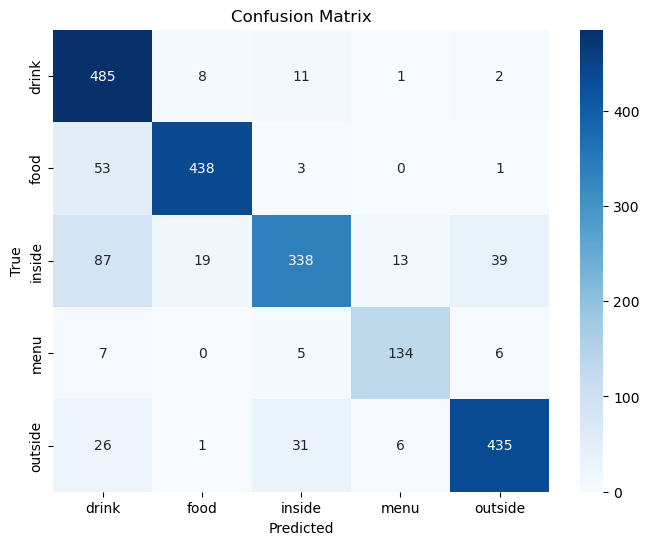

In [51]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=test_gen.class_indices.keys(), 
            yticklabels=test_gen.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [47]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Get true labels and predictions
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

# AUC (multi-class)
y_true_onehot = np.eye(num_classes)[y_true]
auc = roc_auc_score(y_true_onehot, y_pred_probs, multi_class='ovr')
print("AUC Score:", auc)


68/68 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step
Confusion Matrix:
 [[485   8  11   1   2]
 [ 53 438   3   0   1]
 [ 87  19 338  13  39]
 [  7   0   5 134   6]
 [ 26   1  31   6 435]]

Classification Report:
               precision    recall  f1-score   support

       drink       0.74      0.96      0.83       507
        food       0.94      0.88      0.91       495
      inside       0.87      0.68      0.76       496
        menu       0.87      0.88      0.88       152
     outside       0.90      0.87      0.89       499

    accuracy                           0.85      2149
   macro avg       0.86      0.86      0.85      2149
weighted avg       0.86      0.85      0.85      2149

AUC Score: 0.9803892889396295


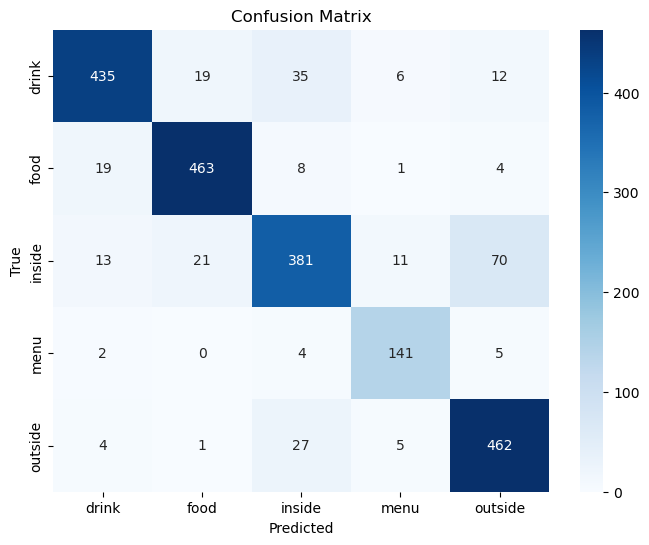

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=test_gen.class_indices.keys(), 
            yticklabels=test_gen.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


Train accuracy (0.89) vs Test accuracy (0.85):

The drop is about 4 percentage points (0.89 → 0.85).

This is normal in real-world deep learning and shows your model generalizes well.

If you were overfitting badly, you'd see much higher train scores and much lower test scores (e.g., train = 0.98, test = 0.70).

AUC is high for both train (0.99) and test (0.98).

Precision, recall, and F1-scores for most classes are consistent across train and test.

**Next Steps**

Add more data/augmentation

Increase dropout

Use early stopping

<h2>Model Interpretability</h2>

In [3]:
from tensorflow.keras.models import load_model

model = load_model('model_checkpoint.keras')  # or 'model_final.keras'



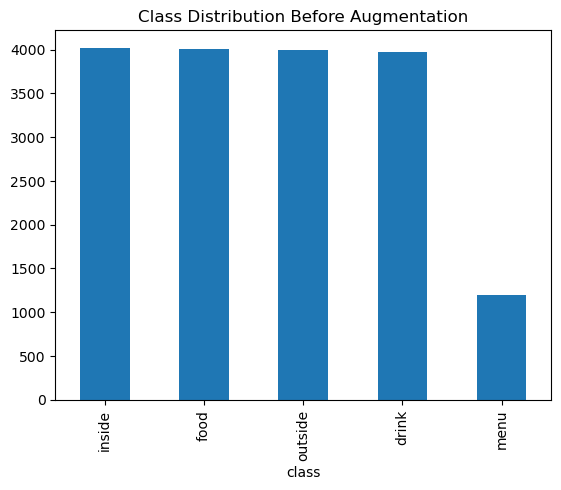

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your train_df has a 'class' column
class_counts = train_df['class'].value_counts()
class_counts.plot(kind='bar')
plt.title("Class Distribution Before Augmentation")
plt.show()


**Confusion Matrix and Per-Class Metrics**


68/68 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step


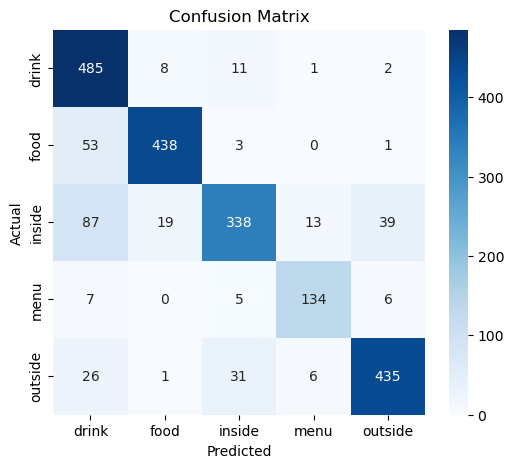

              precision    recall  f1-score   support

       drink       0.74      0.96      0.83       507
        food       0.94      0.88      0.91       495
      inside       0.87      0.68      0.76       496
        menu       0.87      0.88      0.88       152
     outside       0.90      0.87      0.89       499

    accuracy                           0.85      2149
   macro avg       0.86      0.86      0.85      2149
weighted avg       0.86      0.85      0.85      2149



In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_gen.class_indices.keys()),
            yticklabels=list(test_gen.class_indices.keys()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))


High precision and recall for “food” and “drink” indicate the model reliably detects these classes, with “food” showing the highest precision (0.94) and “drink” the highest recall (0.96).

The “inside” class shows lower recall (0.68) and f1-score (0.76), suggesting the model sometimes misclassifies “inside” images, possibly confusing them with visually similar classes like “outside” or “menu.”

“Menu” and “outside” classes also exhibit strong and balanced precision and recall, reflecting robust model performance in those categories.

Overall test accuracy is 85%, with a macro-average f1-score of 0.85, indicating the model generalizes well across different classes.

Most confusion occurs between “inside” and “outside” classes, and occasionally between “food” and “drink.”

The majority of “drink” images are correctly classified, but a small portion is misclassified as “food” or “inside.”

Few “menu” images are misclassified, indicating the model can distinguish menu images effectively, possibly due to unique visual features.

**GradCAM (Visualize What the Model "Sees")**

C:\Users\safna\anaconda3\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['input_layer']. Received: the structure of inputs=*
  warnings.warn(


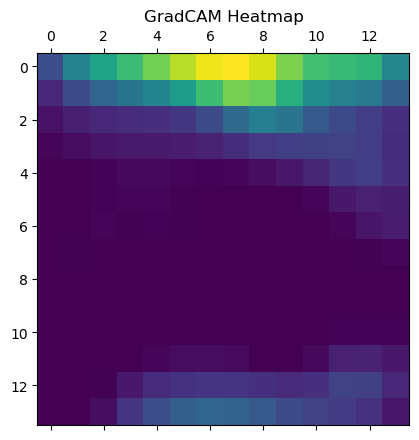

In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def get_img_array(img_path, size):
    # Convert to array and scale
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    array = tf.keras.preprocessing.image.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return array / 255.0

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
       [model.input], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = np.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Example usage:
img_path = 'split_photos/test/4KHb7I8AuZuTpCtzFrYh9w.jpg'
img_array = get_img_array(img_path, size=(224,224))
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name='block5_conv3')  # VGG16 last conv layer

plt.matshow(heatmap)
plt.title("GradCAM Heatmap")
plt.show()


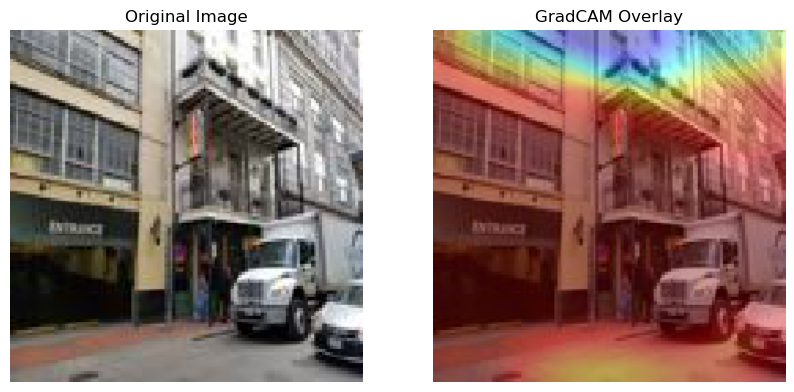

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# 1. Load the original image
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img = tf.keras.preprocessing.image.img_to_array(img) / 255.0

# 2. Resize heatmap to image size (224x224)
heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_resized = np.uint8(255 * heatmap_resized)

# 3. Apply colormap
heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# 4. Superimpose heatmap onto original image
superimposed_img = cv2.addWeighted(np.uint8(img*255), 0.6, heatmap_colored, 0.4, 0)

# 5. Plot
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.axis('off')
plt.title('Original Image')
plt.subplot(1,2,2)
plt.imshow(superimposed_img)
plt.axis('off')
plt.title('GradCAM Overlay')
plt.show()


I used GradCAM to interpret model predictions. The heatmap overlays reveal that the model focused on the upper facade and signage area when identifying the class for this image. This suggests the model is using relevant features (such as architectural elements and text cues) to distinguish between categories (e.g., ‘inside’ vs. ‘outside’). Such visualization helps validate that the model’s attention aligns with human intuition and highlights potential areas for improvement if the focus seems misplaced

**On Misclassified Images**

In [18]:
import numpy as np

misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Number of misclassified images: {len(misclassified_idx)}")


Number of misclassified images: 319


In [19]:
# Get the filenames from the generator's dataframe
misclassified_files = test_gen.filenames if hasattr(test_gen, 'filenames') else test_gen.filepaths
# Make sure you have a list of file paths in the same order as y_true/y_pred

# For demonstration, get info for the first misclassified image:
idx = misclassified_idx[0]
img_path = misclassified_files[idx]

true_class = y_true[idx]
pred_class = y_pred[idx]
print(f"Image: {img_path}, True class: {true_class}, Predicted class: {pred_class}")


Image: split_photos/test/zQfsEG7WwSVrD6yeZsvfeQ.jpg, True class: 2, Predicted class: 0


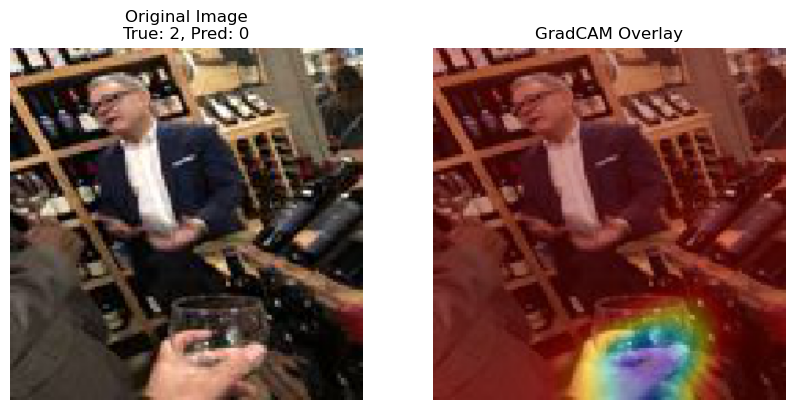

In [20]:
img_array = get_img_array(img_path, size=(224,224))
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name='block5_conv3')

import cv2
import matplotlib.pyplot as plt

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img = tf.keras.preprocessing.image.img_to_array(img) / 255.0

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
superimposed_img = cv2.addWeighted(np.uint8(img*255), 0.6, heatmap_colored, 0.4, 0)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.axis('off')
plt.title(f'Original Image\nTrue: {true_class}, Pred: {pred_class}')
plt.subplot(1,2,2)
plt.imshow(superimposed_img)
plt.axis('off')
plt.title('GradCAM Overlay')
plt.show()


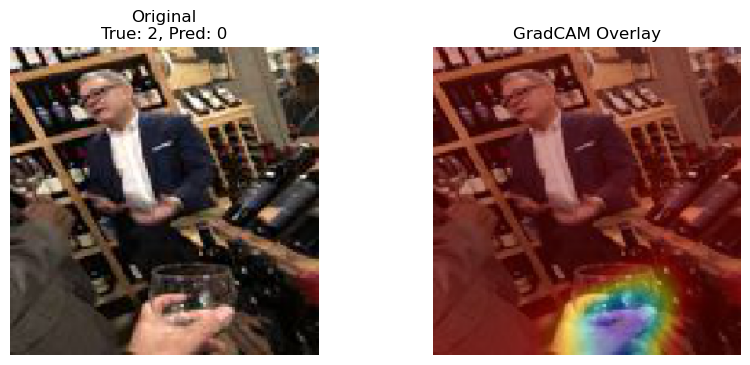

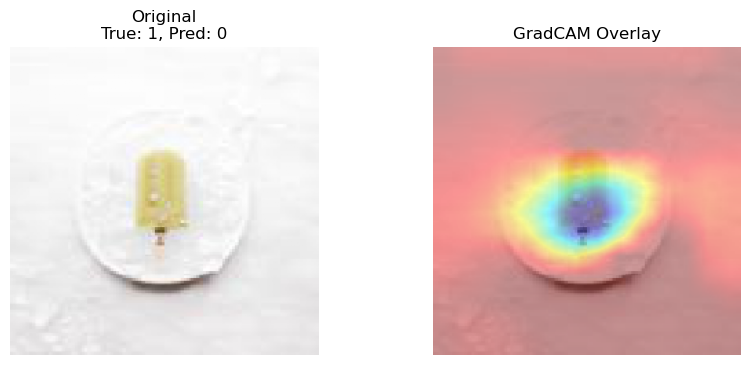

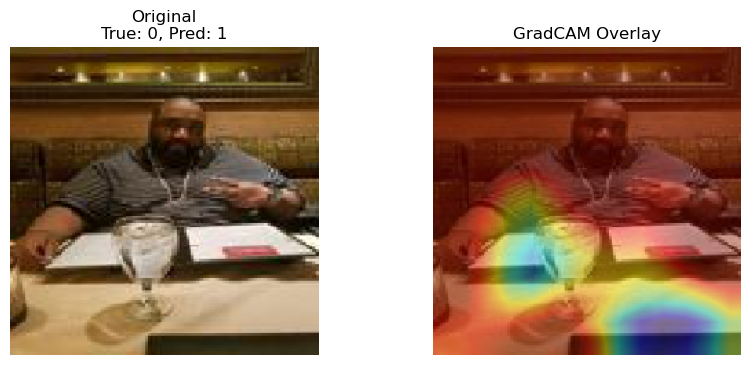

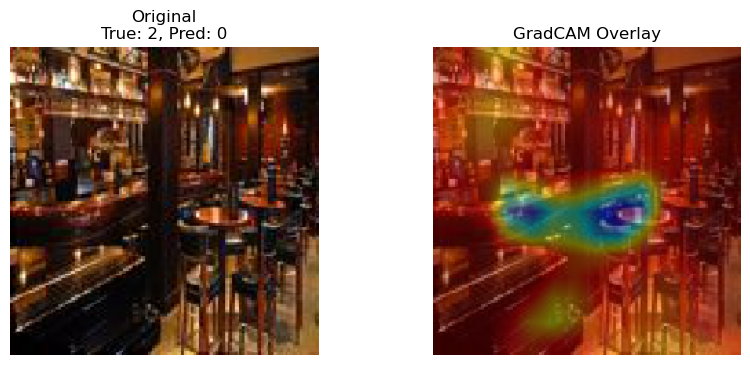

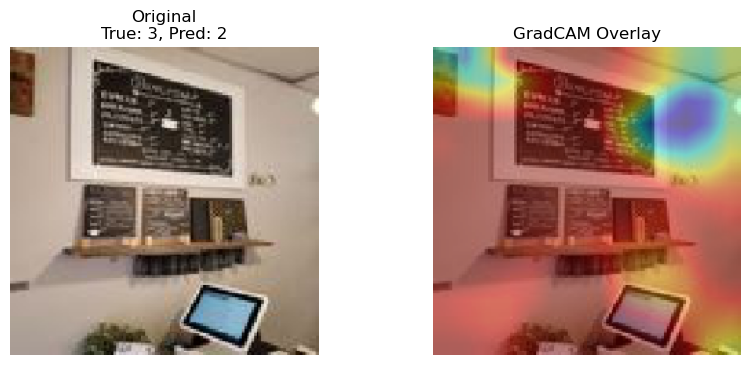

In [21]:
# Loop over first 5 misclassified images
for idx in misclassified_idx[:5]:
    img_path = misclassified_files[idx]
    true_class = y_true[idx]
    pred_class = y_pred[idx]
    img_array = get_img_array(img_path, size=(224,224))
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name='block5_conv3')

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img = tf.keras.preprocessing.image.img_to_array(img) / 255.0

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(np.uint8(img*255), 0.6, heatmap_colored, 0.4, 0)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Original\nTrue: {true_class}, Pred: {pred_class}')
    plt.subplot(1,2,2)
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title('GradCAM Overlay')
    plt.show()


The GradCAM visualizations for misclassified images reveal key insights.
In the first example, the model incorrectly predicted class 0 instead of the true class 1. The heatmap shows the model focused attention on a glass in the foreground, possibly mistaking it for a food or drink item, rather than the overall scene context.
In the second image, a dessert item was classified incorrectly, with the model attending primarily to the central region of the plate, missing subtle cues in the broader presentation.
These cases highlight the model’s potential over-reliance on prominent objects while ignoring broader scene cues, suggesting a need for further data-centric improvements or more context-aware architectures.

Over-reliance on Salient, but Non-Discriminative Features:
Sometimes, the model is distracted by backgrounds, utensils, or decor instead of the subject (e.g., for “inside” vs. “outside” it might focus on windows, lighting, or people instead of context cues).

Confusion Between Visually Similar Classes:
GradCAM can show that, for example, “inside” and “outside” images might have overlapping focus regions, indicating why the model finds these classes hard to separate.

**This insight can guide data-centric improvements:**

*More training images for confusing classes,

*Targeted augmentation,

*Or redesigning class definitions.